# Model Analysis
All functions can be found in src/functions.py.

In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
sys.path.append("../src")
from functions import *


In [2]:
development_df, train_df, val_df, evaluation_df = load_data_preprocessing(
    development_path="../data/development_data.csv",
    evaluation_path="../data/evaluation_data.csv"
)
metadata_cols, cpg_cols, target_col = get_feature_groups(train_df)



Loading development dataset

Loading dataset from: ../data/development_data.csv
The first rows of the dataset             age             ethnicity sex  cg16867657  cg06639320  cg24724428  \
sample_id                                                                      
GSM990554   79  Caucasian - European   M    0.672001    0.504461    0.331257   
GSM990278   46    Hispanic - Mexican   M    0.555411    0.389214    0.160708   
GSM990589   78  Caucasian - European   M    0.781318    0.554360    0.337578   
GSM990323   46    Hispanic - Mexican   F    0.542491    0.435584    0.228723   
GSM990116   59    Hispanic - Mexican   F    0.653190    0.466217    0.208453   

           cg07553761  cg22454769  cg06784991  cg21572722  ...  cg17321954  \
sample_id                                                  ...               
GSM990554    0.327287    0.572867    0.309496    0.444902  ...    0.174936   
GSM990278    0.230875    0.464971    0.223665    0.381837  ...    0.154691   
GSM990589    0.

---
# Task 2: Baseline Models

## 2.1 OLS Linear Regression
We run this to the  training set and then we wil evaluate on validation set with **1000 bootstrap resamples, seed=42**!!
In this stage, we chose Ordinary Least Squares (OLS) Linear Regression as our baseline model. The model was trained separately on three feature sets: metadata only, CpG features only, and the combination of both. By  choosing this simple model, it is possible for us to assess id other models, provide improvements in performance or not. Each model was trained only once on the training set obtained from the development split in Task 1.1, without applying cross-validation or hyperparameter tuning, as required for a true baseline evaluation. After training, predictions were generated on the validation set. Next step, to evaluate performance, we performed bootstrap resampling was applied only to the validation predictions, using 1000 resamples with a fixed random seed of 42. This approach allowed the estimation of the variability of the evaluation metrics and the construction of 95% confidence intervals. The evaluation of model performance was conducted employing four metrics: Root Mean Squared Error (RMSE), Mean Absolute Error (MAE), coefficient of determination (R²), and Pearson correlation coefficient (r). Along with the bootstrap confidence intervals, metrics were calculated on the complete validation set to offer a unified central performance estimate. This assessment framework establishes a strong and equitable benchmark for future tasks, where model tuning and feature selection will be integrated.

In [3]:
for feature_name in ['metadata', 'cpg', 'all']:
    print(f'\n OLS - {feature_name.upper()} features')
    feature_cols      = get_feature_set(train_df, feature_set=feature_name)
    X_train, y_train  = split_features_target(train_df, feature_cols)
    X_val,   y_val    = split_features_target(val_df,   feature_cols)
    selected_meta     = [c for c in metadata_cols if c in feature_cols]
    selected_cpg      = [c for c in cpg_cols      if c in feature_cols]
    preprocessor      = build_preprocessor(selected_cpg, selected_meta)
    X_train_p         = preprocessor.fit_transform(X_train)
    X_val_p           = preprocessor.transform(X_val)
    y_pred            = train_ols_model(X_train_p, y_train, X_val_p)
    ols_results     = evaluate_model(y_val, y_pred)


 OLS - METADATA features

Evaluating model using bootstrap

Validation metrics with 95% CI:
RMSE: 12.9545 (95% CI: 10.5730 - 15.4597)
MAE: 9.8540 (95% CI: 8.2067 - 11.7093)
R^2: 0.2138 (95% CI: 0.0510 - 0.3648)
Pearson r: 0.4629 (95% CI: 0.2991 - 0.6253)

 OLS - CPG features

Evaluating model using bootstrap

Validation metrics with 95% CI:
RMSE: 5.2731 (95% CI: 4.0635 - 6.5458)
MAE: 4.0006 (95% CI: 3.2965 - 4.6899)
R^2: 0.8697 (95% CI: 0.7875 - 0.9235)
Pearson r: 0.9355 (95% CI: 0.8930 - 0.9650)

 OLS - ALL features

Evaluating model using bootstrap

Validation metrics with 95% CI:
RMSE: 5.2576 (95% CI: 4.0582 - 6.5256)
MAE: 3.9915 (95% CI: 3.2988 - 4.6716)
R^2: 0.8705 (95% CI: 0.7878 - 0.9243)
Pearson r: 0.9360 (95% CI: 0.8937 - 0.9654)


## Results
Now it is clear that CpG methylation features are the main important featuresfor chronological age. The metadata-only model performed very bad, with lower R^2 and high error values, while  the CpG-only model achieved strong predictive performance and also adding metadata to the CpG features resulted in almost no more improvement. 

## 2.2 Three Regression Models at Default Hyperparameters

All trained on **CpG-only** feature set (1000 features). Evaluated with same bootstrap protocol.

In [4]:
feature_cols      = get_feature_set(train_df, feature_set='cpg')
X_train, y_train  = split_features_target(train_df, feature_cols)
X_val,   y_val    = split_features_target(val_df,   feature_cols)
selected_cpg      = [c for c in cpg_cols if c in feature_cols]
preprocessor      = build_preprocessor(selected_cpg, [])
X_train_p         = preprocessor.fit_transform(X_train)
X_val_p           = preprocessor.transform(X_val)

In [5]:
print('ElasticNet')
y_pred_elastic           = train_elastic_net_model(X_train_p, y_train, X_val_p)
elastic_results = evaluate_model(y_val, y_pred_elastic)

ElasticNet
Elastic_net model
Elastic Net model trained successfully.
Predictions made on the val data.

Evaluating model using bootstrap

Validation metrics with 95% CI:
RMSE: 5.5131 (95% CI: 4.3695 - 6.8731)
MAE: 4.0937 (95% CI: 3.3488 - 4.8785)
R^2: 0.8576 (95% CI: 0.7707 - 0.9109)
Pearson r: 0.9334 (95% CI: 0.8886 - 0.9632)


In [6]:
print(' SVR')
y_pred_svr         = train_SVR_model(X_train_p, y_train, X_val_p)
svr_results     = evaluate_model(y_val, y_pred_svr)

 SVR
SVR model with RBF kernel
SVR_model succesfully done
Predictions made on the val data.

Evaluating model using bootstrap

Validation metrics with 95% CI:
RMSE: 8.9233 (95% CI: 7.2349 - 10.6252)
MAE: 6.4736 (95% CI: 5.3430 - 7.8107)
R^2: 0.6270 (95% CI: 0.5374 - 0.7041)
Pearson r: 0.8464 (95% CI: 0.7804 - 0.8984)


In [7]:
print('BayesianRidge')
y_pred_bayes           = train_BayesianRidge_model(X_train_p, y_train, X_val_p)
bayes_results   = evaluate_model(y_val, y_pred_bayes)

BayesianRidge
Bayesian Ridge model
Bayesian Ridge model traind successfully.
Predictions made on the val data.

Evaluating model using bootstrap

Validation metrics with 95% CI:
RMSE: 4.7284 (95% CI: 3.6219 - 5.9787)
MAE: 3.5355 (95% CI: 2.9191 - 4.1763)
R^2: 0.8953 (95% CI: 0.8252 - 0.9401)
Pearson r: 0.9500 (95% CI: 0.9134 - 0.9734)


### Bootstrap Boxplots — RMSE and R^2


Model Performance Summary:

        Model              RMSE (CI)              MAE (CI)               R² (CI)        Pearson r (CI)
          OLS  5.258 (4.058 - 6.526) 3.991 (3.299 - 4.672) 0.870 (0.788 - 0.924) 0.936 (0.894 - 0.965)
   ElasticNet  5.513 (4.370 - 6.873) 4.094 (3.349 - 4.878) 0.858 (0.771 - 0.911) 0.933 (0.889 - 0.963)
          SVR 8.923 (7.235 - 10.625) 6.474 (5.343 - 7.811) 0.627 (0.537 - 0.704) 0.846 (0.780 - 0.898)
BayesianRidge  4.728 (3.622 - 5.979) 3.536 (2.919 - 4.176) 0.895 (0.825 - 0.940) 0.950 (0.913 - 0.973)


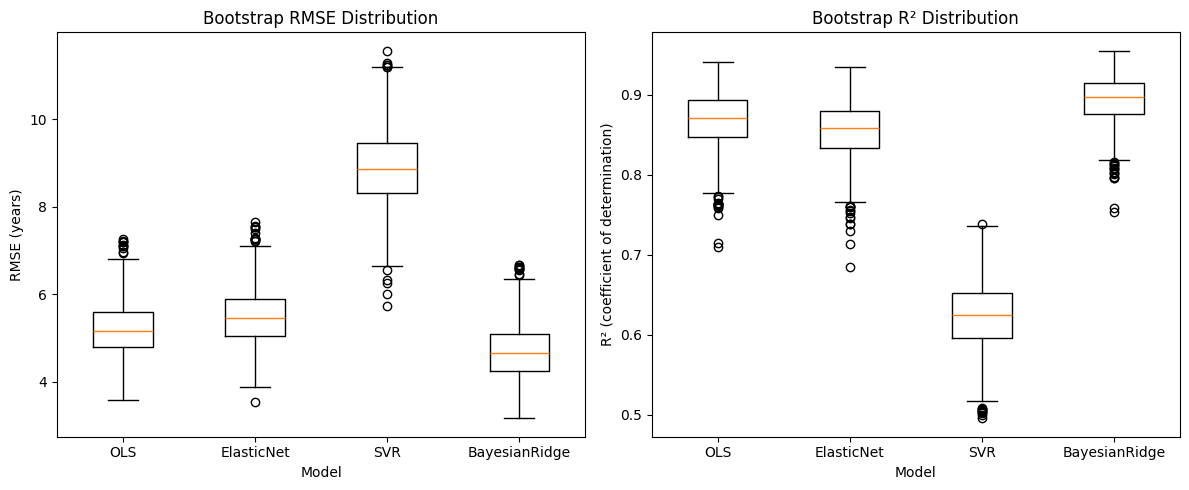

In [8]:
results = {
    'OLS'          : ols_results,
    'ElasticNet'   : elastic_results,
    'SVR'          : svr_results,
    'BayesianRidge': bayes_results,
}

print_results_table(results)
plot_bootstrap_boxplots(results)

### Results
The results reveal clear performance differences across the four baseline models. BayesianRidge achieved the best performance overall, with the lowest RMSE (4.728) and MAE (3.536) and the highest R² (0.895) and Pearson r (0.950), outperforming the OLS baseline across all metrics. OLS itself performed strongly (RMSE: 5.258, R²: 0.870), confirming that CpG methylation features carry strong predictive signal even without regularisation. ElasticNet performed slightly worse than OLS (RMSE: 5.513, R²: 0.858), suggesting that the default L1+L2 regularisation may be too aggressive with untuned hyperparameters, shrinking useful coefficients. SVR with an RBF kernel performed the worst of all models (RMSE: 8.923, R²: 0.627), failing to beat the OLS baseline. This is likely due to the default hyperparameters being poorly suited to the high-dimensional CpG feature space (1000 features). The confidence intervals for BayesianRidge and OLS show minimal overlap with SVR, confirming that the performance gap is meaningful and not due to sampling variability. Overall, BayesianRidge is the only model that clearly beats the OLS floor and justifies inclusion in subsequent tasks. ElasticNet and SVR would require hyperparameter tuning to be competitive.Based on these results, BayesianRidge is carried forward to subsequent tasks, while ElasticNet and SVR would require hyperparameter tuning to be competitive.

---
# Task 3: Feature Selection

## 3.1 Stability Selection

In this task, stability selection was employed as a method for detecting the CpG features that consistently correlate with age under different perturbations of the data. Stability selection is a data resampling-based framework in the context of machine learning, which is intended for the improvement of the performance of variable selection algorithms, especially in the case of high-dimensional data or when the number of features is significantly greater than the number of data samples. The approach was first proposed by Meinshausen and Bühlmann in 2010, with the aim of addressing the instability of selection procedures, like the popular LASSO method, which often vary the selected features even under minor changes in the data. The underlying idea behind this algorithm is that the relevant features should always be selected, even under minor changes in the data. Thus, the algorithm is useful for reducing the effects of sampling instability. The algorithm was applied using the training data. First, 50 subsamples were drawn, each consisting of 80% of the data in the training set, sampled randomly without replacement. For each subsample, only the CpG features were used. The missing values were imputed using the median, computed for each subsample.Then, the absolute Spearman correlation between each CpG feature and age was computed, and the top 200 features with the strongest correlations were retained.After repeating this process across all 50 subsamples, the number of times each CpG feature was selected was counted. A feature was considered stable if it appeared in more than half of the resamples, meaning it was selected more than 25 times out of 50. The final output of this step included the number of stable features identified, as well as the selection-frequency distribution across all CpG probes.

Resample 1/50 done
Resample 2/50 done
Resample 3/50 done
Resample 4/50 done
Resample 5/50 done
Resample 6/50 done
Resample 7/50 done
Resample 8/50 done
Resample 9/50 done
Resample 10/50 done
Resample 11/50 done
Resample 12/50 done
Resample 13/50 done
Resample 14/50 done
Resample 15/50 done
Resample 16/50 done
Resample 17/50 done
Resample 18/50 done
Resample 19/50 done
Resample 20/50 done
Resample 21/50 done
Resample 22/50 done
Resample 23/50 done
Resample 24/50 done
Resample 25/50 done
Resample 26/50 done
Resample 27/50 done
Resample 28/50 done
Resample 29/50 done
Resample 30/50 done
Resample 31/50 done
Resample 32/50 done
Resample 33/50 done
Resample 34/50 done
Resample 35/50 done
Resample 36/50 done
Resample 37/50 done
Resample 38/50 done
Resample 39/50 done
Resample 40/50 done
Resample 41/50 done
Resample 42/50 done
Resample 43/50 done
Resample 44/50 done
Resample 45/50 done
Resample 46/50 done
Resample 47/50 done
Resample 48/50 done
Resample 49/50 done
Resample 50/50 done
Stable fe

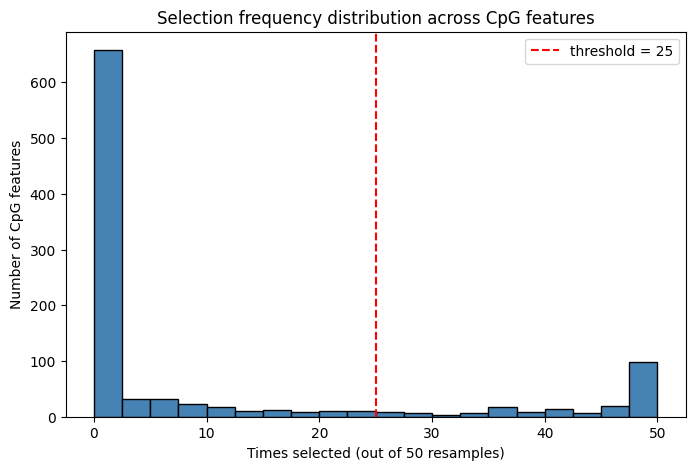

Top 10 most stable CpGs:
cg16867657    50
cg06639320    50
cg24724428    50
cg07553761    50
cg22454769    50
cg06784991    50
cg21572722    50
cg24079702    50
cg03032497    50
cg08234504    50
dtype: int64
Stable features selected: 186


In [9]:
stable_features, counts = stability_selection(train_df)
plot_frequency(counts)
stable_cpg_cols = stable_features.index.tolist()
print('Top 10 most stable CpGs:')
print(stable_features.sort_values(ascending=False).head(10))
print('Stable features selected:', len(stable_cpg_cols))

## 3.2 mRMR Feature Selection

The mRMR approach was used to overcome stability selection's drawback when managing redundant features. The goal of mRMR is to choose features that are both minimally redundant with one another and strongly related to the target variable (age), in contrast to stability selection, which primarily considers the repeated importance of individual features. In other words, rather than choosing numerous highly correlated CpG sites that might represent the same biological signal, the approach seeks to retain features that offer complementary and helpful information.
The CpG-only feature space was used to apply the method solely to the training set. Several candidate values were tested, including 50, 75, 90, 100, 120, 150,200 because mRMR requires that the number of selected features, K, be predetermined.The corresponding number of CpG features from the training data was chosen using mRMR for each value of K. The chosen features were then used to train a basic Bayesian Ridge model, which was then assessed using RMSE on the validation set. The selection of Kto was guided by predictive performance thanks to this validation-based comparison, which balanced the need to preserve sufficient biological signal with the avoidance of needless redundancy.
The value of K that produced the lowest validation RMSE was chosen as the optimal value. The smaller value of K was favored when two values provided very similar performance because it results in a lower dimensionality model that is easier to understand. This adheres to the general rule that when performance differences are minimal, parsimony is preferred. After final subset of CpG features was obtained by running mRMR on the training set with the optimal value of K. In order to demonstrate which probes had the strongest relationship with the target variable, the top 10 chosen features were then reported along with their importance scores, which were expressed here as their absolute Spearman correlation with age.
Lastly, a visual representation of the overlap between the features chosen by stability selection and those chosen by mRMR was presented. The degree of agreement between the two feature selection strategies is evaluated through this comparison. While variations between the approaches show the contrast between choosing features based only on stability and choosing features based on both relevance, features that appear in both sets may be particularly trustworthy.

Trying K=   50


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:07<00:00,  6.80it/s]


  K=50 gave RMSE = 5.7042
Trying K=   75


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 75/75 [00:10<00:00,  7.19it/s]


  K=75 gave RMSE = 5.6341
Trying K=   90


...

  K=120 gave RMSE = 5.4499
Trying K=   150


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 150/150 [00:20<00:00,  7.22it/s]


  K=150 gave RMSE = 5.7096
Trying K=   200


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [00:28<00:00,  6.99it/s]


  K=200 gave RMSE = 5.4870

Best K = 120 with RMSE = 5.4499
(if two K values give similar RMSE, we prefer the smaller one because it is simpler)


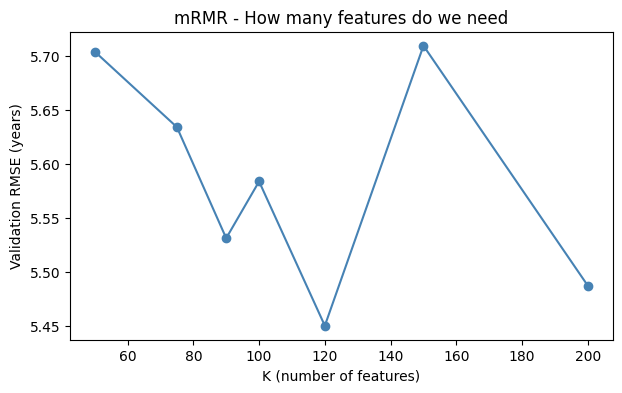

Best K: 120


In [10]:
best_k = choose_best_k(train_df, val_df)
print('Best K:', best_k)

In [11]:
mrmr_features = run_mrmr(train_df, K=best_k)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 120/120 [00:16<00:00,  7.34it/s]

mRMR selected 120 features
Top 10 features:
  1. cg16867657  (Spearman r = 0.8557)
  2. cg06639320  (Spearman r = 0.7602)
  3. cg10501210  (Spearman r = 0.7005)
  4. cg24724428  (Spearman r = 0.7651)
  5. cg22454769  (Spearman r = 0.7271)
  6. cg21572722  (Spearman r = 0.7133)
  7. cg19283806  (Spearman r = 0.6659)
  8. cg14692377  (Spearman r = 0.6964)
  9. cg08234504  (Spearman r = 0.7041)
  10. cg24079702  (Spearman r = 0.7062)


### Overlap between Stability and mRMR

Stability only : 92
Overlap        : 94
mRMR only      : 26


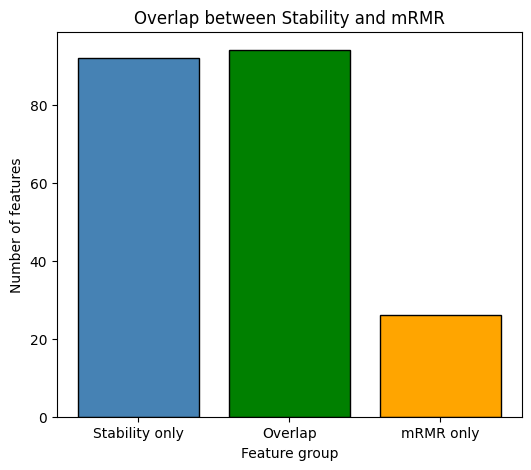

In [12]:
plot_overlap(stable_cpg_cols, mrmr_features)

## 3.3 Method Comparison

We evaluate both feature sets using BayesianRidge as a proxy model on the validation set.

In [13]:
best_features, best_method = compare_feature_sets(train_df, val_df, stable_cpg_cols, mrmr_features)
print('Best method:', best_method)
print('Number of features:', len(best_features))

Bayesian Ridge model
Bayesian Ridge model traind successfully.
Predictions made on the val data.
Stability: 186 features, RMSE=5.5056, R2=0.8580
Bayesian Ridge model
Bayesian Ridge model traind successfully.
Predictions made on the val data.
mRMR: 120 features, RMSE=5.4499, R2=0.8609

Comparison Table
Method       N features   RMSE       R2
Stability    186          5.5056    0.8580
mRMR         120          5.4499    0.8609

Best method: mRMR
RMSE: 5.4499
Number of features: 120
This feature we will use for  Task 4
Best method: mRMR
Number of features: 120


---
# Task 4: Hyperparameter Tuning and Final Evaluation

## 4.1 Hyperparameter Tuning
The three regression models ElasticNet, SVR, and Bayesian Ridge were subjected to hyperparameter tuning following the selection of the most informative feature set in Task 3. This step's objective was to find better model configurations than the baseline stage's default settings in order to enhance predictive performance.
In accordance with the assignment requirement that the evaluation set be kept fully locked until the final assessment stage, tuning was carried out using RandomizedSearchCV with 5-fold cross-validation on the development data only. To guarantee reproducibility, a random seed of 42 was used throughout. The goal was to minimize the mean cross-validation RMSE for each model by testing at least forty different random hyperparameter combinations.
For ElasticNet, the search focused on the regularisation strength (alpha) and the balance between L1 and L2 penalty (l1_ratio). For SVR, the hyperparameters explored were C, epsilon, and the kernel type (rbf or linear). For Bayesian Ridge, the priors controlling regularisation (alpha_1, alpha_2, lambda_1, and lambda_2) were sampled from log-uniform distributions. After the search process was completed, the best hyperparameter combination for each model was identified based on the lowest cross-validation RMSE.
Finally, each model was refit using its best hyperparameters on the full development dataset, that is, the combined training and validation sets. This was done so that the final models could make use of all available development data before being evaluated once on the locked evaluation set.

In [14]:
elastic_best, svr_best, bayes_best = tune_model(development_df, best_features)


Using the best selected feature set, we tune ElasticNet, SVR, and BayesianRidge with RandomizedSearchCV and 5-fold CV on the full development dataset.
Tuning ElasticNet
Best ElasticNet params: {'model__alpha': np.float64(0.2801635158716261), 'model__l1_ratio': np.float64(0.22554447458683766)}
Tuning SVR
Best SVR params: {'model__C': np.float64(0.11916299962955149), 'model__epsilon': 0.1, 'model__kernel': 'linear'}
Tuning BayesianRidge
Best BayesianRidge params: {'model__alpha_1': np.float64(3.798214508453255e-07), 'model__alpha_2': np.float64(9.074256288983855e-06), 'model__lambda_1': np.float64(0.0008761971101023686), 'model__lambda_2': np.float64(9.294394155644988e-07)}


## 4.2 Final Evaluation on Evaluation Set

After hyperparameter tuning, the final selected models were evaluated on the locked evaluation dataset. This dataset had not been used during preprocessing choices, feature selection, or model tuning, ensuring that the final performance estimates remained unbiased.
For each tuned model, predictions were generated on the evaluation set using the selected feature subset. Performance was then assessed using bootstrap resampling of the evaluation set, with 1000 resamples and a fixed random seed of 42. In each bootstrap iteration, pairs of true and predicted age values were sampled with replacement, and four evaluation metrics were calculated: Root Mean Squared Error (RMSE), Mean Absolute Error (MAE), coefficient of determination (R^2), and Pearson correlation coefficient (r).
For every metric, the mean and standard deviation across the 1000 bootstrap samples were computed, together with the 95% confidence interval estimated from the bootstrap distribution. In addition, predictions on the full evaluation set were used as the basis for the bootstrap analysis. This approach provides not only a central estimate of model performance, but also a measure of uncertainty and stability.
The final comparison of the tuned models was based primarily on RMSE, as specified in the assignment, while MAE, R^2, and Pearson r were also reported to provide a more complete picture of predictive performance. This final evaluation makes it possible to determine which tuned model generalizes best to unseen methylation data and therefore represents the strongest final epigenetic age predictor.

In [15]:
print('FINAL EVALUATION in ElasticNet')
elastic_results = evaluate_in_evaluation_data(elastic_best, evaluation_df, best_features)

FINAL EVALUATION in ElasticNet
Now let's evaluate with  evaluation data

Evaluation metrics with bootstrap:
RMSE: mean=4.9240, std=0.6572, 95% CI=(3.7374, 6.2428)
MAE: mean=3.5065, std=0.3415, 95% CI=(2.8720, 4.1947)
R^2: mean=0.8751, std=0.0391, 95% CI=(0.7867, 0.9373)
Pearson r: mean=0.9370, std=0.0203, 95% CI=(0.8909, 0.9693)


In [16]:
print('FINAL EVALUATION in SVR')
svr_results = evaluate_in_evaluation_data(svr_best, evaluation_df, best_features)

FINAL EVALUATION in SVR
Now let's evaluate with  evaluation data

Evaluation metrics with bootstrap:
RMSE: mean=5.1763, std=0.6350, 95% CI=(3.9649, 6.4710)
MAE: mean=3.6940, std=0.3631, 95% CI=(3.0246, 4.4370)
R^2: mean=0.8623, std=0.0406, 95% CI=(0.7674, 0.9276)
Pearson r: mean=0.9315, std=0.0206, 95% CI=(0.8835, 0.9653)


In [17]:
print(' FINAL EVALUATION with BayesianRidge')
bayes_results = evaluate_in_evaluation_data(bayes_best, evaluation_df, best_features)

 FINAL EVALUATION with BayesianRidge
Now let's evaluate with  evaluation data

Evaluation metrics with bootstrap:
RMSE: mean=4.9315, std=0.6343, 95% CI=(3.8034, 6.2005)
MAE: mean=3.5421, std=0.3388, 95% CI=(2.9236, 4.2349)
R^2: mean=0.8749, std=0.0382, 95% CI=(0.7880, 0.9368)
Pearson r: mean=0.9375, std=0.0197, 95% CI=(0.8931, 0.9693)


In [18]:
print("ElasticNet")
print_stage_table("ElasticNet", {"FS+Tuned": elastic_results})

print("\nSVR")
print_stage_table("SVR", {"FS+Tuned": svr_results})

print("\n BayesianRidge ")
print_stage_table("BayesianRidge", {"FS+Tuned": bayes_results})


print("\ Final Comparison")
for name, res in [("ElasticNet", elastic_results), ("SVR", svr_results), ("BayesianRidge", bayes_results)]:
    print(f"{name}: RMSE={res['RMSE_mean']:.4f} ± {res['RMSE_std']:.4f} ({res['RMSE_CI'][0]:.4f} - {res['RMSE_CI'][1]:.4f})")


ElasticNet
     Model    Stage RMSE (mean)         95% CI   MAE    R² Pearson r
ElasticNet FS+Tuned       4.924 [3.737, 6.243] 3.507 0.875     0.937

SVR
Model    Stage RMSE (mean)         95% CI   MAE    R² Pearson r
  SVR FS+Tuned       5.176 [3.965, 6.471] 3.694 0.862     0.932

 BayesianRidge 
        Model    Stage RMSE (mean)         95% CI   MAE    R² Pearson r
BayesianRidge FS+Tuned       4.931 [3.803, 6.200] 3.542 0.875     0.938
\ Final Comparison
ElasticNet: RMSE=4.9240 ± 0.6572 (3.7374 - 6.2428)
SVR: RMSE=5.1763 ± 0.6350 (3.9649 - 6.4710)
BayesianRidge: RMSE=4.9315 ± 0.6343 (3.8034 - 6.2005)


## 4.3 Model Selection

Based on bootstrap RMSE, CI width, complexity, and interpretability, we select the best model and save it. Bootstrap boxplots for each metric across all three models. A scatter plot of Predicted vs Actual Age for each tuned model on the evaluation set. 

Best model: ElasticNet
RMSE: 4.924
Model saved to ../models/best_model.pkl
Model loaded back successfully!
The best model is: ElasticNet and it is saved


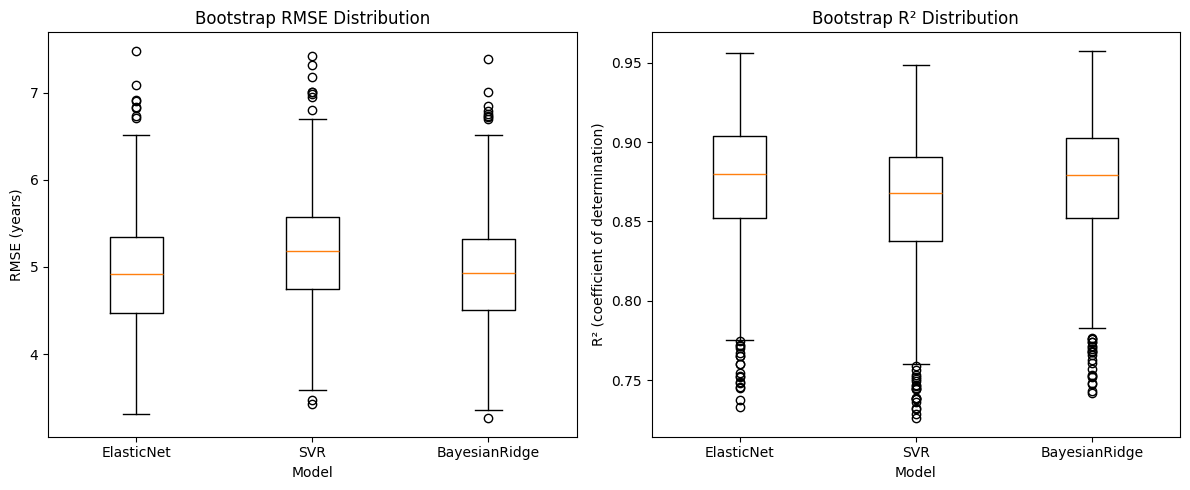

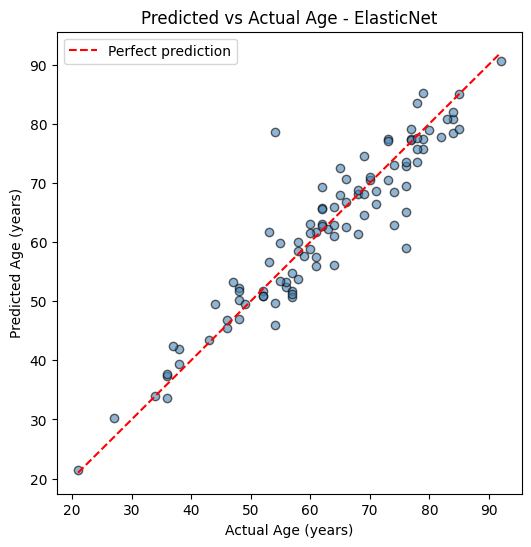

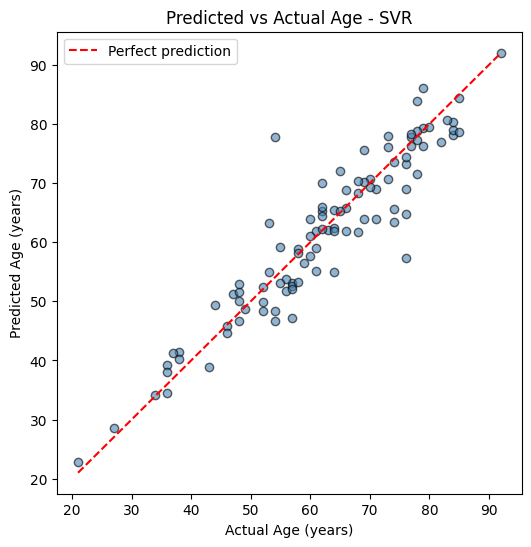

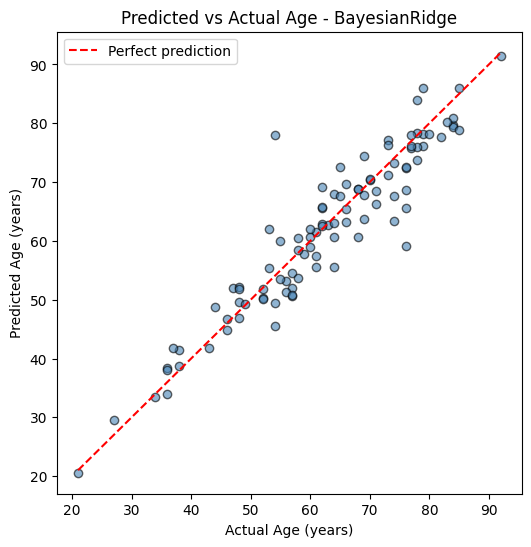

In [19]:
# save the best model
best_model_name, best_model_obj = save_best_model(
    elastic_results, svr_results, bayes_results,
    elastic_best, svr_best, bayes_best
)

print('The best model is:', best_model_name , 'and it is saved')

tuned_results = {
    'ElasticNet'   : elastic_results,
    'SVR'          : svr_results,
    'BayesianRidge': bayes_results
}
plot_bootstrap_boxplots(tuned_results)


plot_predicted_vs_actual(evaluation_df["age"].values,
                         elastic_best.predict(evaluation_df[best_features]),
                         "ElasticNet")
plot_predicted_vs_actual(evaluation_df["age"].values,
                         svr_best.predict(evaluation_df[best_features]),
                         "SVR")
plot_predicted_vs_actual(evaluation_df["age"].values,
                         bayes_best.predict(evaluation_df[best_features]),
                         "BayesianRidge")

---
# Bonus A: Optuna Hyperparameter Optimization 



[I 2026-03-30 03:36:48,670] A new study created in memory with name: no-name-02293a69-3c33-4f02-8883-4ea36debc0d1


Starting Optuna search for elasticnet...
We will try 50 different combinations of hyperparameters


Best trial: 39. Best value: 4.7426: 100%|██████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:12<00:00,  3.97it/s]


Done! Best RMSE found: 4.7426
Best hyperparameters: {'alpha': 0.760420918999944, 'l1_ratio': 0.10377504001204996}
Starting Optuna search for svr...
We will try 50 different combinations of hyperparameters


Best trial: 45. Best value: 4.94777: 100%|█████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [31:31<00:00, 37.82s/it]


Done! Best RMSE found: 4.9478
Best hyperparameters: {'C': 0.10090127372913159, 'epsilon': 1.0, 'kernel': 'linear'}
Starting Optuna search for bayesianridge...
We will try 50 different combinations of hyperparameters


Best trial: 33. Best value: 4.80977: 100%|█████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:16<00:00,  2.98it/s]


Done! Best RMSE found: 4.8098
Best hyperparameters: {'alpha_1': 4.697456896562919e-06, 'alpha_2': 0.0005755701014084219, 'lambda_1': 0.0009694721250968633, 'lambda_2': 1.614259269410308e-07}


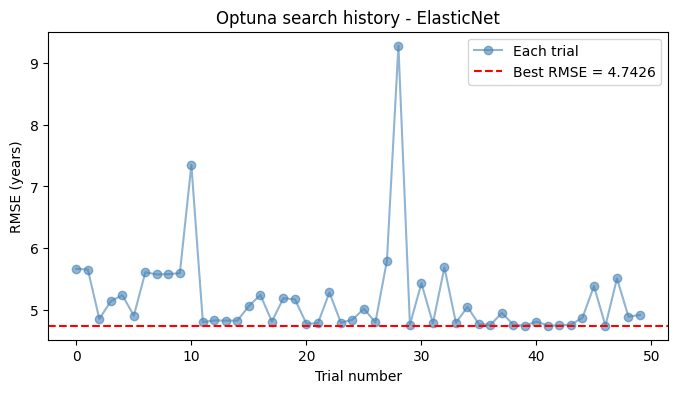


RandomSearch vs Optuna - Head to Head:
Model           RandomSearch    Optuna          Delta      Winner
-----------------------------------------------------------------
ElasticNet      4.9240          4.7426          0.1814     Optuna
SVR             5.1763          4.9478          0.2285     Optuna
BayesianRidge   4.9315          4.8098          0.1217     Optuna


In [20]:
# prepare the data
X_dev = development_df[best_features]
y_dev = development_df["age"].values

# build a fresh pipeline for each model
elastic_pipe_opt = Pipeline([("preprocessor", build_preprocessor(best_features, [])), ("model", ElasticNet())])
svr_pipe_opt     = Pipeline([("preprocessor", build_preprocessor(best_features, [])), ("model", SVR())])
bayes_pipe_opt   = Pipeline([("preprocessor", build_preprocessor(best_features, [])), ("model", BayesianRidge())])

# run optuna for each model 
elastic_optuna, elastic_study = optuna_tune_model("elasticnet",    elastic_pipe_opt, X_dev, y_dev, n_trials=50)
svr_optuna,     svr_study     = optuna_tune_model("svr",           svr_pipe_opt,     X_dev, y_dev, n_trials=50)
bayes_optuna,   bayes_study   = optuna_tune_model("bayesianridge", bayes_pipe_opt,   X_dev, y_dev, n_trials=50)

# plot the search history for ElasticNet
plot_optuna_history(elastic_study, "ElasticNet")

# compare optuna vs random search
print_optuna_comparison(elastic_results, svr_results, bayes_results,
                        elastic_study, svr_study, bayes_study)

---
# Bonus B: Sex Prediction from DNA Methylation

DNA methylation is closely linked to sex biology via X-inactivation.In this task, the problem wwe rerun the machine learning procedure BUT as a binary classification task, where the target was sex and not age. So, firslty he had to convert the sex column to a binary label, where  females was 0 and males was 1. We expect that sex-related methylation patterns are to be stronger and biologically more distinct from the distributed signal associated with ageing. Using the sex label as the target, the mRMR method was used once more to choose informative CpG features for sex prediction. The objective was to minimize redundancy between chosen features while simultaneously identifying CpG sites that were highly relevant for differentiating between males and females. This is significant because the CpG probes that best distinguish between the two sex classes are not always the same as those that are most informative for age prediction. Following feature selection, the biological signals recorded by the two tasks were compared by visualizing the overlap between the age-selected and sex-selected CpG sets. The two sets were essentially non-overlapping, as predicted, indicating that sex and age are linked to distinct methylation signatures.
Two classification models were then trained using the selected sex-related CpG features: Logistic Regression and Gaussian Naive Bayes. Logistic Regression was chosen as a simple linear classifier with L2 regularisation, offering interpretable coefficients and calibrated probability estimates. Gaussian Naive Bayes was included as a fast and simple generative classifier, based on the assumption that features are conditionally independent given the class label.Bootstrap resampling with 1000 resamples and a random seed of 42 was used to assess the models on the evaluation set. Predictions and class probabilities were created for every bootstrap sample, and accuracy, F1 score, Matthews Correlation Coefficient (MCC), ROC-AUC, and PR-AUC were used to assess performance. The entire evaluation set was used to compute these metrics, and the bootstrap distributions were used to estimate the 95% confidence intervals. This evaluation framework offers a reliable method for comparing the two approaches' performance and evaluating classifier stability.

In [21]:
print("\n BONUS B-Sex Prediction")
train_df, evaluation_df = create_sex_label(train_df, evaluation_df)


 BONUS B-Sex Prediction
Sex labels created


Running mRMR for sex with K=120


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 120/120 [00:17<00:00,  6.68it/s]


Selected 120 features for sex
Age only  : 177
Overlap   : 9
Sex only  : 111


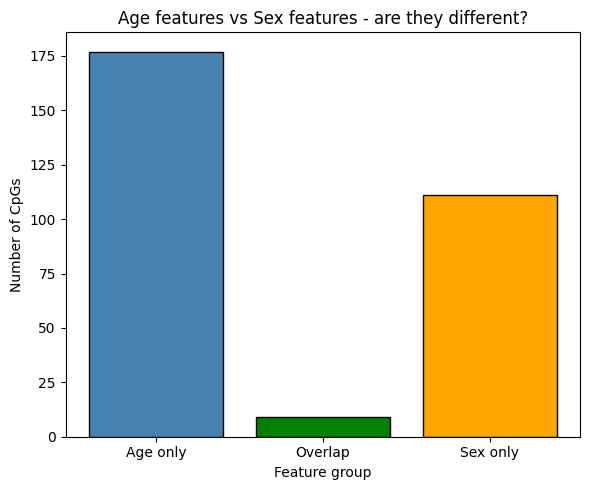

In [22]:
sex_features = select_sex_features(train_df, K=best_k)
plot_sex_age_overlap(stable_cpg_cols, sex_features)

In [23]:
preprocessor  = build_preprocessor(sex_features, [])
X_train_sex   = preprocessor.fit_transform(train_df[sex_features])
X_eval_sex    = preprocessor.transform(evaluation_df[sex_features])
y_train_sex   = train_df['sex_label']
y_eval_sex    = evaluation_df['sex_label']
lr, gnb       = train_classifiers(X_train_sex, y_train_sex)

Training Logistic Regression
Done!
Training Gaussian Naive Bayes
Done!


In [24]:
print(' Logistic Regression ')
lr_scores = evaluate_classifier(lr, X_eval_sex, y_eval_sex)

 Logistic Regression 
Accuracy : 0.8900  (95% CI: 0.8300 - 0.9500)
F1       : 0.8675  (95% CI: 0.7792 - 0.9375)
MCC      : 0.7736  (95% CI: 0.6403 - 0.8941)
ROC-AUC  : 0.9491  (95% CI: 0.9034 - 0.9850)
PR-AUC   : 0.9448  (95% CI: 0.8841 - 0.9842)


In [25]:
print(' Gaussian Naive Bayes ')
gnb_scores = evaluate_classifier(gnb, X_eval_sex, y_eval_sex)

 Gaussian Naive Bayes 
Accuracy : 0.6200  (95% CI: 0.5200 - 0.7100)
F1       : 0.5250  (95% CI: 0.3810 - 0.6446)
MCC      : 0.2104  (95% CI: 0.0087 - 0.3899)
ROC-AUC  : 0.6856  (95% CI: 0.5766 - 0.7880)
PR-AUC   : 0.5523  (95% CI: 0.4186 - 0.7119)


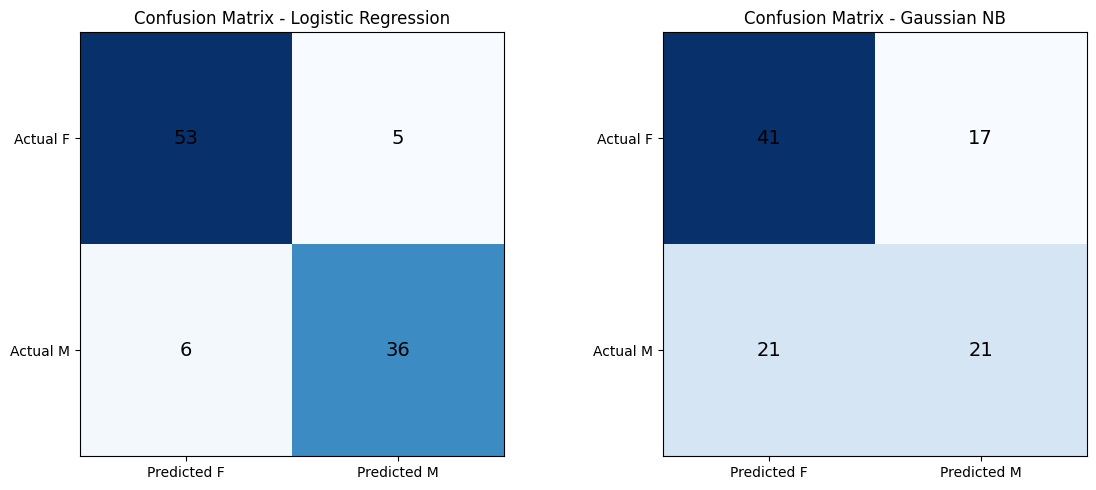

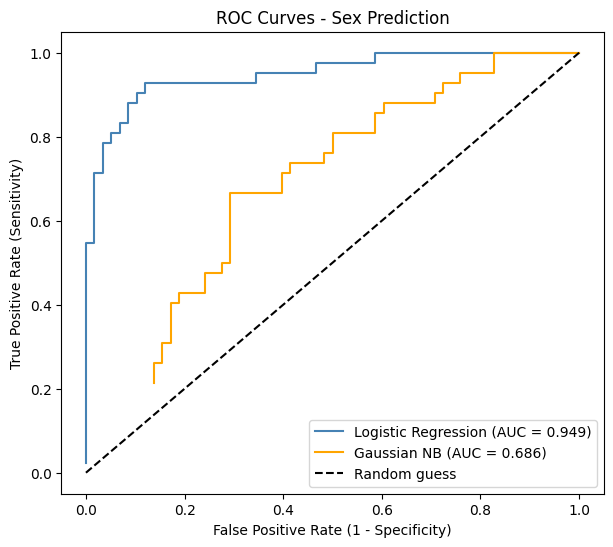

Calculating correlation of each CpG with sex...
Top CpG: cg05207637 with r = 0.3262


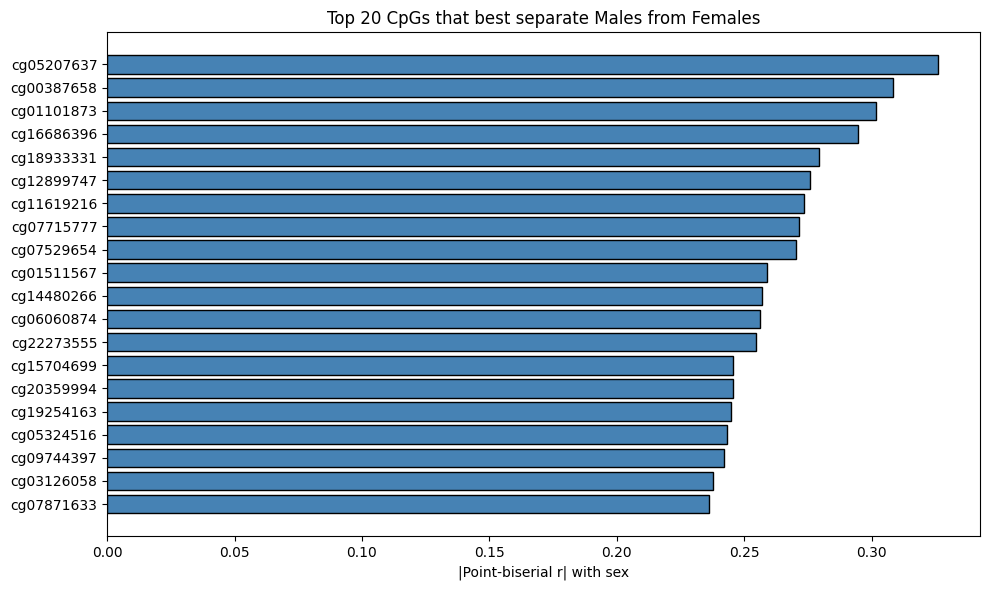

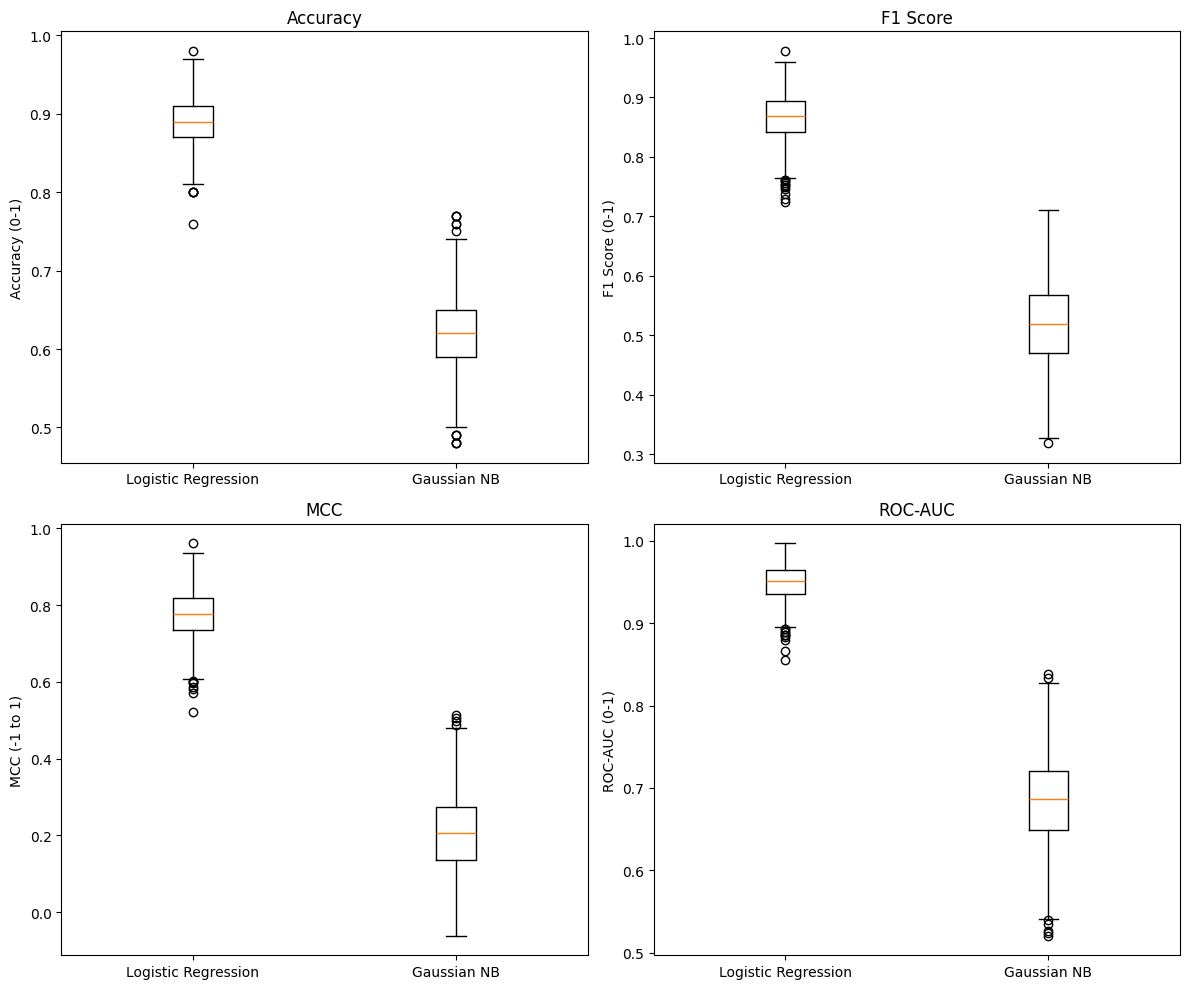

In [26]:
plot_confusion_matrices(lr, gnb, X_eval_sex, evaluation_df["sex_label"].values)

# how good  separating M from F
plot_roc_curves(lr, gnb, X_eval_sex, evaluation_df["sex_label"].values)

# which best CpGs best predict sex?
plot_top20_sex_cpgs(train_df)

plot_classifier_boxplots(lr_scores, gnb_scores)